# RSNA Knee MRI — Mini 集抽样

> **目标**：基于 EDA 结论，生成 Mini 集 exam ID 列表，供后续下载 DICOM 使用。
>
> **策略**：正样本全集 + 正常样本随机补足


## 0. 导入


In [8]:
import pandas as pd
import numpy as np
from pathlib import Path

SEED = 2026
np.random.seed(SEED)

DATA_DIR = Path('../data/metadata')
OUTPUT_DIR = Path('../data/processed')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COLS = [
    'ACL', 'MCL',
    'Medial Meniscus', 'Lateral Meniscus',
    'Medial OA', 'Lateral OA', 'PF OA',
    'Effusion', 'Synovitis', "Baker's",
    'Contusion', 'Fracture'
]


## 1. 加载数据


In [9]:
train = pd.read_csv(DATA_DIR / 'train.csv')
series = pd.read_csv(DATA_DIR / 'train_series.csv')

# 清洗标签
for col in TARGET_COLS:
    train[col] = pd.to_numeric(train[col], errors='coerce').fillna(0).astype(int)

print(f'全量 exam: {len(train)}')
print(f'全量序列: {len(series)}')


全量 exam: 4407
全量序列: 24371


## 2. 分离正负样本


In [10]:
# 正样本：至少有 1 个异常标签的 exam
train['n_labels'] = train[TARGET_COLS].sum(axis=1)
positive_mask = train['n_labels'] > 0

pos_exams = train[positive_mask].copy()
neg_exams = train[~positive_mask].copy()

n_pos = len(pos_exams)
n_neg = len(neg_exams)

print(f'异常 exam（>=1 label）: {n_pos}')
print(f'完全正常 exam:          {n_neg}')
print(f'异常比例:               {n_pos / len(train) * 100:.2f}%')

# 检查标签覆盖
print(f'\n异常 exam 中各标签覆盖:')
for col in TARGET_COLS:
    total_pos = train[col].sum()
    in_pos_set = pos_exams[col].sum()
    print(f'  {col:20s}: {int(in_pos_set)}/{int(total_pos)}'
          f' (覆盖 {in_pos_set/total_pos*100:.0f}%)')


异常 exam（>=1 label）: 58
完全正常 exam:          4349
异常比例:               1.32%

异常 exam 中各标签覆盖:
  ACL                 : 24/24 (覆盖 100%)
  MCL                 : 9/9 (覆盖 100%)
  Medial Meniscus     : 26/26 (覆盖 100%)
  Lateral Meniscus    : 23/23 (覆盖 100%)
  Medial OA           : 15/15 (覆盖 100%)
  Lateral OA          : 11/11 (覆盖 100%)
  PF OA               : 21/21 (覆盖 100%)
  Effusion            : 35/35 (覆盖 100%)
  Synovitis           : 27/27 (覆盖 100%)
  Baker's             : 12/12 (覆盖 100%)
  Contusion           : 19/19 (覆盖 100%)
  Fracture            : 18/18 (覆盖 100%)


## 3. 构建 Mini 集

> 目标 ~600 exam（从之前的 350 上调，充分利用磁盘空间）。
> 正样本 58 个全取，剩余从正常 exam 中随机抽样补足。


In [11]:
TARGET_SIZE = 600
N_NEG = TARGET_SIZE - n_pos

print(f'目标 Mini 集大小: {TARGET_SIZE}')
print(f'异常 exam（全部）: {n_pos}')
print(f'正常 exam（随机）: {N_NEG}')

# 随机抽样正常 exam
neg_selected = neg_exams.sample(n=N_NEG, random_state=SEED)

# 合并
mini_set = pd.concat([pos_exams, neg_selected], ignore_index=True)
mini_set['split'] = 'mini'

# 剩下的正常 exam 可用于后续扩充
neg_remaining = neg_exams.drop(neg_selected.index)
print(f'\n剩余未选正常 exam: {len(neg_remaining)}（可用于后续扩容）')

# 保存
mini_set[['StudyInstanceUID', 'split']].to_csv(
    OUTPUT_DIR / 'mini_set_exams.csv', index=False
)
print(f'\n已保存: data/processed/mini_set_exams.csv')
print(f'共 {len(mini_set)} 个 exam')


目标 Mini 集大小: 600
异常 exam（全部）: 58
正常 exam（随机）: 542

剩余未选正常 exam: 3807（可用于后续扩容）

已保存: data/processed/mini_set_exams.csv
共 600 个 exam


## 4. 验证 Mini 集标签分布


In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_style('whitegrid')

# Mini vs Full 标签分布对比
full_prev = train[TARGET_COLS].mean() * 100
mini_prev = mini_set[TARGET_COLS].mean() * 100

compare = pd.DataFrame({
    'Full Dataset (%)': full_prev.round(2),
    'Mini Set (%)': mini_prev.round(2),
    'n_pos_full': train[TARGET_COLS].sum().astype(int),
    'n_pos_mini': mini_set[TARGET_COLS].sum().astype(int),
}).sort_values('Full Dataset (%)', ascending=False)

print('标签分布对比 (Full vs Mini):')
print(compare.to_string())
print(f'\nMini 集正样本覆盖率:')
for col in TARGET_COLS:
    n_full = int(train[col].sum())
    n_mini = int(mini_set[col].sum())
    print(f'  {col:20s}: {n_mini}/{n_full} ({n_mini/n_full*100:.0f}%)')


标签分布对比 (Full vs Mini):
                  Full Dataset (%)  Mini Set (%)  n_pos_full  n_pos_mini
Effusion                      0.79          5.83          35          35
Synovitis                     0.61          4.50          27          27
Medial Meniscus               0.59          4.33          26          26
ACL                           0.54          4.00          24          24
Lateral Meniscus              0.52          3.83          23          23
PF OA                         0.48          3.50          21          21
Contusion                     0.43          3.17          19          19
Fracture                      0.41          3.00          18          18
Medial OA                     0.34          2.50          15          15
Baker's                       0.27          2.00          12          12
Lateral OA                    0.25          1.83          11          11
MCL                           0.20          1.50           9           9

Mini 集正样本覆盖率:
  ACL        

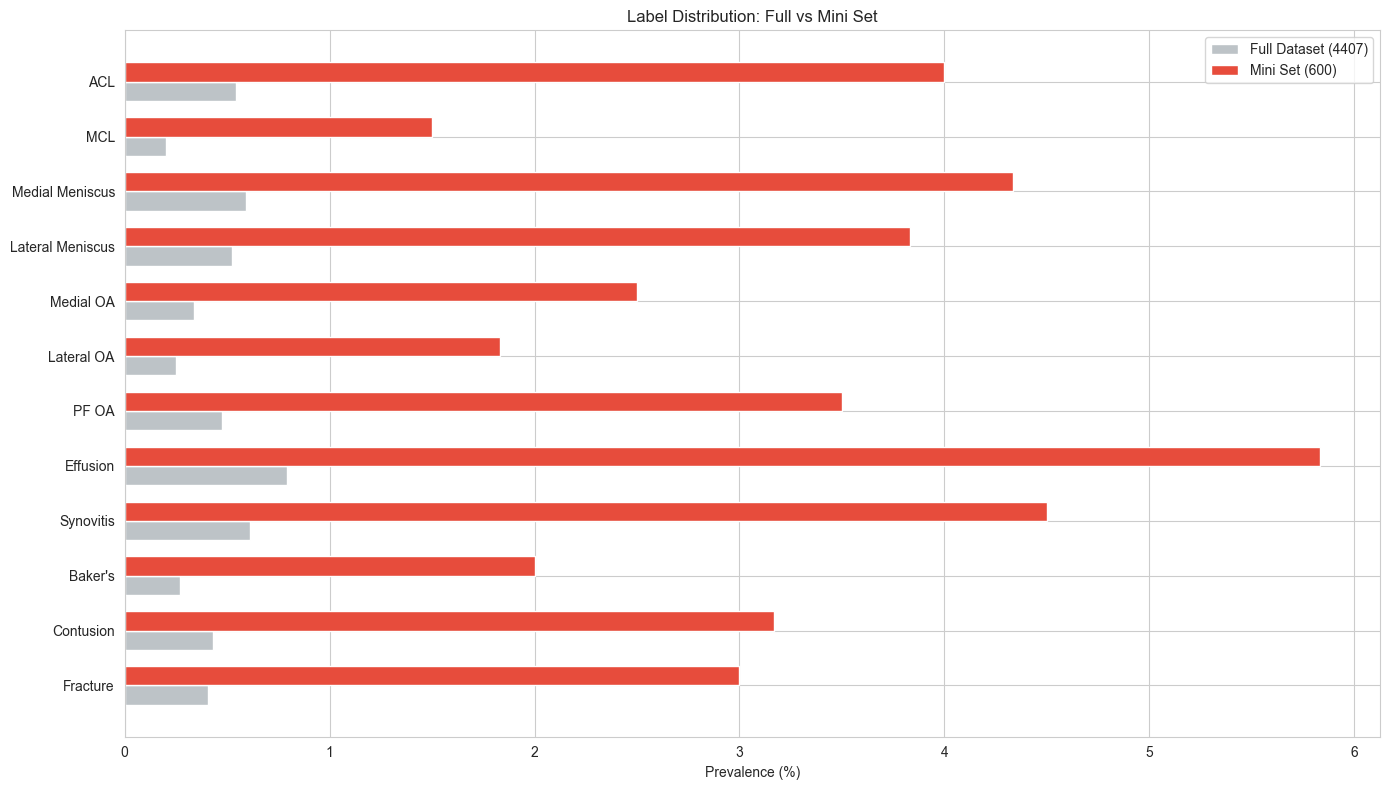

In [13]:
# 可视化对比
fig, ax = plt.subplots(figsize=(14, 8))

x = range(len(TARGET_COLS))
width = 0.35

bars1 = ax.barh([i + width/2 for i in x], full_prev[TARGET_COLS],
                width, color='#bdc3c7', edgecolor='white', label='Full Dataset (4407)')
bars2 = ax.barh([i - width/2 for i in x], mini_prev[TARGET_COLS],
                width, color='#e74c3c', edgecolor='white', label=f'Mini Set ({len(mini_set)})')

ax.set_yticks(x)
ax.set_yticklabels(TARGET_COLS)
ax.set_xlabel('Prevalence (%)')
ax.set_title(f'Label Distribution: Full vs Mini Set')
ax.legend()
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'mini_set_label_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. 关联下载序列（三级降级策略）

> 对每个 Mini 集 exam，优先选主力诊断序列。
> 找不到则逐级降级，确保 600 个 exam 全部有序列可下载。


In [14]:
# Tier 1: Sagittal + FS + Fluid（主力诊断序列）
tier1 = series[
    (series['Anatomical_Plane'] == 'Sagittal')
    & (series['Fat_Suppression'] == 1)
    & (series['Fluid_Sensitive'] == 1)
]
# Tier 2: 任意 Sagittal（降级）
tier2 = series[series['Anatomical_Plane'] == 'Sagittal']
# Tier 3: 任意序列（兜底，取第一条）
tier3 = series

# 逐 exam 匹配
results = []
tier_counts = {1: 0, 2: 0, 3: 0}

for _, row in mini_set.iterrows():
    sid = row['StudyInstanceUID']

    # Tier 1
    p = tier1[tier1['StudyInstanceUID'] == sid]
    tier = 1
    if len(p) == 0:
        # Tier 2: 任意 Sagittal
        p = tier2[tier2['StudyInstanceUID'] == sid]
        tier = 2
    if len(p) == 0:
        # Tier 3: 兜底，取第一条可用序列
        p = tier3[tier3['StudyInstanceUID'] == sid].head(1)
        tier = 3

    for _, sr in p.iterrows():
        results.append({
            'StudyInstanceUID': sid,
            'SeriesInstanceUID': sr['SeriesInstanceUID'],
            'tier': tier,
            'plane': sr['Anatomical_Plane'],
            'fs': int(sr['Fat_Suppression']),
            'fluid': int(sr['Fluid_Sensitive'])
        })
        tier_counts[tier] += 1

download_list = pd.DataFrame(results)

print('=== 序列匹配结果 ===')
print(f'Tier 1 (Sagittal FS Fluid): {tier_counts[1]} 条序列')
print(f'Tier 2 (任何 Sagittal):     {tier_counts[2]} 条序列')
print(f'Tier 3 (兜底任意序列):      {tier_counts[3]} 条序列')
print(f'总计: {len(download_list)} 条序列')
print(f'覆盖 exam: {download_list["StudyInstanceUID"].nunique()}/{len(mini_set)}')

# Tier 分布（按 exam 最高 tier）
exam_tier = download_list.groupby('StudyInstanceUID')['tier'].min().value_counts().sort_index()
print(f'\n每 exam 最佳 tier:')
for t, c in exam_tier.items():
    label = {1: 'T1 主力', 2: 'T2 降级 Sagittal', 3: 'T3 兜底'}[t]
    print(f'  {label}: {c} exams')

download_list.to_csv(OUTPUT_DIR / 'mini_set_download_list.csv', index=False)
print(f'\n已保存: data/processed/mini_set_download_list.csv')


=== 序列匹配结果 ===
Tier 1 (Sagittal FS Fluid): 640 条序列
Tier 2 (任何 Sagittal):     64 条序列
Tier 3 (兜底任意序列):      0 条序列
总计: 704 条序列
覆盖 exam: 600/600

每 exam 最佳 tier:
  T1 主力: 568 exams
  T2 降级 Sagittal: 32 exams

已保存: data/processed/mini_set_download_list.csv


## 6. 后续步骤

1. ✅ 标签分布分析
2. ✅ Mini 集 exam ID 导出（本 notebook）
3. ⬜ DICOM 下载（`03_download_dicom.ipynb`）
4. ⬜ Mini 集验证（`04_validate_miniset.ipynb`）
